In [ ]:
import pandas as pd
df = pd.read_csv("df_cleaned_2020_final_modeling.csv")
print(df.shape)

In [2]:
import pandas as pd
df = pd.read_csv("df_cleaned_2018_2020_final_modeling.csv")
print(df.shape)

(17234, 34)


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load dataset
df = pd.read_csv("df_cleaned_2020_final_modeling.csv")
X = df.drop(columns=['log_qc701'])
y = df['log_qc701']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Train Baseline Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# 4. Evaluate Performance
y_pred_train = gb_model.predict(X_train)
y_pred_test = gb_model.predict(X_test)

# Calculate MSE separately for clarity
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

print("=== GRADIENT BOOSTING RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_pred_train):.4f} | Test R²:   {r2_score(y_test, y_pred_test):.4f}")
print(f"Train MSE:  {train_mse:.4f} | Test MSE:  {test_mse:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse):.4f} | Test RMSE: {np.sqrt(test_mse):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train):.4f} | Test MAE:  {mean_absolute_error(y_test, y_pred_test):.4f}")

=== GRADIENT BOOSTING RESULTS ===
Train R²:   0.1093 | Test R²:   0.0828
Train MSE:  2.0606 | Test MSE:  2.1341
Train RMSE: 1.4355 | Test RMSE: 1.4609
Train MAE:  0.9117 | Test MAE:  0.9016


In [3]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load dataset
df = pd.read_csv('df_cleaned_2018_2020_final_modeling.csv')
X = df.drop(columns=['log_qc701'])
y = df['log_qc701']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Train Baseline Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# 4. Evaluate Performance
y_pred_train = gb_model.predict(X_train)
y_pred_test = gb_model.predict(X_test)

# Calculate MSE separately for clarity
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

print("=== GRADIENT BOOSTING RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_pred_train):.4f} | Test R²:   {r2_score(y_test, y_pred_test):.4f}")
print(f"Train MSE:  {train_mse:.4f} | Test MSE:  {test_mse:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse):.4f} | Test RMSE: {np.sqrt(test_mse):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train):.4f} | Test MAE:  {mean_absolute_error(y_test, y_pred_test):.4f}")

=== GRADIENT BOOSTING RESULTS ===
Train R²:   0.6239 | Test R²:   0.5771
Train MSE:  0.8992 | Test MSE:  1.0204
Train RMSE: 0.9483 | Test RMSE: 1.0101
Train MAE:  0.4082 | Test MAE:  0.4351


In [5]:
## Hyperparameter Tuning via RandomizedSearchCV

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize model and search
gb_model = GradientBoostingRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_gb = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'subsample': 0.7, 'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 4, 'learning_rate': 0.01}


In [6]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

# ===============================
# 1. Define Features and Target
# ===============================
X = df.drop(columns=['log_qc701'])
y = df['log_qc701']

# ===============================
# 2. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ===============================
# 3. Train Optimized Gradient Boosting Model
# ===============================
best_model = GradientBoostingRegressor(
    subsample=0.7,
    n_estimators=500,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features=None,
    max_depth=4,
    learning_rate=0.01,
    random_state=42
)

best_model.fit(X_train, y_train)

# ===============================
# 4. Predictions
# ===============================
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# ===============================
# 5. Evaluation
# ===============================
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# ===============================
# 6. Print Results
# ===============================
print("=" * 60)
print("OPTIMIZED GRADIENT BOOSTING RESULTS")
print("=" * 60)

print(f"Train R²   : {train_r2:.4f} | Test R²    : {test_r2:.4f}")

print(f"\nTrain MSE  : {train_mse:.4f} | Test MSE   : {test_mse:.4f}")

print(f"\nTrain RMSE : {train_rmse:.4f} | Test RMSE  : {test_rmse:.4f}")

print(f"\nTrain MAE  : {train_mae:.4f} | Test MAE   : {test_mae:.4f}")

OPTIMIZED GRADIENT BOOSTING RESULTS
Train R²   : 0.6329 | Test R²    : 0.5833

Train MSE  : 0.8778 | Test MSE   : 1.0055

Train RMSE : 0.9369 | Test RMSE  : 1.0027

Train MAE  : 0.3983 | Test MAE   : 0.4238


In [7]:
## Implement Early Stopping

# Re-fit using early stopping validation set
gb_early = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    validation_fraction=0.15,
    n_iter_no_change=15,
    tol=1e-4,
    random_state=42
)

gb_early.fit(X_train, y_train)
print(f"Optimal number of trees stopped at: {gb_early.n_estimators_}")

Optimal number of trees stopped at: 191


In [8]:
!pip install lightgbm

In [9]:
## Extract & Evaluate Your Early Stopping GB Model

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict using the early-stopped model
y_train_pred_gb = gb_early.predict(X_train)
y_test_pred_gb = gb_early.predict(X_test)

# Calculate MSE separately for clarity
mse_train_gb = mean_squared_error(y_train, y_train_pred_gb)
mse_test_gb = mean_squared_error(y_test, y_test_pred_gb)

print("==================================================")
print("   GRADIENT BOOSTING (EARLY STOPPING) RESULTS     ")
print("==================================================")
print(
    f"Train R²  : {r2_score(y_train, y_train_pred_gb):.4f}  | Test R²  : {r2_score(y_test, y_test_pred_gb):.4f}")
print(
    f"Train MSE : {mse_train_gb:.4f}  | Test MSE : {mse_test_gb:.4f}")  # Added MSE here
print(
    f"Train RMSE: {np.sqrt(mse_train_gb):.4f}  | Test RMSE: {np.sqrt(mse_test_gb):.4f}")
print(
    f"Train MAE : {mean_absolute_error(y_train, y_train_pred_gb):.4f}  | Test MAE : {mean_absolute_error(y_test, y_test_pred_gb):.4f}")

print("==================================================")

   GRADIENT BOOSTING (EARLY STOPPING) RESULTS     
Train R²  : 0.6385  | Test R²  : 0.5794
Train MSE : 0.8644  | Test MSE : 1.0149
Train RMSE: 0.9298  | Test RMSE: 1.0074
Train MAE : 0.3989  | Test MAE : 0.4302


In [10]:
##Run LightGBM with Early Stopping & Regularization 

import lightgbm as lgb

# Initialize LightGBM Regressor
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,  # L1 regularization
    reg_lambda=1.0, # L2 regularization
    random_state=42
)

# Fit model with early stopping
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# Predict & Evaluate
y_train_pred_lgb = lgb_model.predict(X_train)
y_test_pred_lgb = lgb_model.predict(X_test)

# Calculate MSE separately for clarity
mse_train_gb = mean_squared_error(y_train, y_train_pred_lgb)
mse_test_gb = mean_squared_error(y_test, y_test_pred_lgb)

print("=== LIGHTGBM ENHANCED RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_train_pred_lgb):.4f} | Test R²:   {r2_score(y_test, y_test_pred_lgb):.4f}")
print(f"Train MSE : {mse_train_gb:.4f}  | Test MSE : {mse_test_gb:.4f}") 
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_lgb)):.4f} | Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_lgb)):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_train_pred_lgb):.4f} | Test MAE:  {mean_absolute_error(y_test, y_test_pred_lgb):.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1090
[LightGBM] [Info] Number of data points in the train set: 13787, number of used features: 33
[LightGBM] [Info] Start training from score 6.738059
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


In [12]:
##inspect Feature Importance & Prune Low-Value Features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Extract feature importances
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Select top features above threshold
selected_features = importance_df[importance_df['Importance'] > 5]['Feature'].tolist()
print(f"Retaining {len(selected_features)} out of {X_train.shape[1]} features...")

# 3. Filter training and testing datasets
X_train_filtered = X_train[selected_features]
X_test_filtered = X_test[selected_features]

# 4. Retrain LightGBM model on filtered features
lgb_model_filtered = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

lgb_model_filtered.fit(
    X_train_filtered, y_train,
    eval_set=[(X_test_filtered, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# 5. Predict on train and test sets
y_train_pred_filt = lgb_model_filtered.predict(X_train_filtered)
y_test_pred_filt = lgb_model_filtered.predict(X_test_filtered)

# 6. Calculate explicit MSE values
train_mse = mean_squared_error(y_train, y_train_pred_filt)
test_mse = mean_squared_error(y_test, y_test_pred_filt)

# 7. Print all evaluation metrics matching your notebook format
print("\n=== LIGHTGBM (FEATURE FILTERED) RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_train_pred_filt):.4f} | Test R²:   {r2_score(y_test, y_test_pred_filt):.4f}")
print(f"Train MSE:  {train_mse:.4f} | Test MSE:  {test_mse:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse):.4f} | Test RMSE: {np.sqrt(test_mse):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_train_pred_filt):.4f} | Test MAE:  {mean_absolute_error(y_test, y_test_pred_filt):.4f}")

Retaining 28 out of 33 features...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000583 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1080
[LightGBM] [Info] Number of data points in the train set: 13787, number of used features: 28
[LightGBM] [Info] Start training from score 6.738059
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


In [13]:
!pip install optuna

In [11]:
import lightgbm as lgb
import numpy as np
import optuna
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Suppress Optuna logging for clean output
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Create a validation split FROM training data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)


# 2. Define Optuna Objective Function
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.1, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "verbose": -1,
    }

    model = LGBMRegressor(**params)

    # Use X_tr and X_val HERE instead of X_train_filtered!
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],
    )

    preds = model.predict(X_val)
    return mean_squared_error(y_val, preds)


# 3. Execute Optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best Hyperparameters Found:", study.best_params)

# 4. Train Final Model on full training set (X_train)
best_lgb = LGBMRegressor(**study.best_params, random_state=42, verbose=-1)
best_lgb.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],
)

# 5. Predict & Calculate Metrics using X_train and X_test
y_train_pred_opt = best_lgb.predict(X_train)
y_test_pred_opt = best_lgb.predict(X_test)

train_mse_opt = mean_squared_error(y_train, y_train_pred_opt)
test_mse_opt = mean_squared_error(y_test, y_test_pred_opt)

# 6. Output Evaluation Results
print("\n==================================================")
print("     OPTUNA OPTIMIZED LIGHTGBM RESULTS            ")
print("==================================================")
print(
    f"Train R²  : {r2_score(y_train, y_train_pred_opt):.4f}  | Test R²  : {r2_score(y_test, y_test_pred_opt):.4f}"
)

print(f"Train MSE : {train_mse_opt:.4f}  | Test MSE : {test_mse_opt:.4f}")
print(
    f"Train RMSE: {np.sqrt(train_mse_opt):.4f}  | Test RMSE: {np.sqrt(test_mse_opt):.4f}"
)
print(
    f"Train MAE : {mean_absolute_error(y_train, y_train_pred_opt):.4f}  | Test MAE : {mean_absolute_error(y_test, y_test_pred_opt):.4f}"
)

print("==================================================")

C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval

Best Hyperparameters Found: {'n_estimators': 466, 'learning_rate': 0.03575277826795917, 'max_depth': 5, 'num_leaves': 70, 'min_child_samples': 30, 'subsample': 0.7255766029283579, 'colsample_bytree': 0.6972329514858664, 'reg_alpha': 7.383551295519219e-07, 'reg_lambda': 1.3635758829581168}

     OPTUNA OPTIMIZED LIGHTGBM RESULTS            
Train R²  : 0.6392  | Test R²  : 0.5890
Train MSE : 0.8627  | Test MSE : 0.9917
Train RMSE: 0.9288  | Test RMSE: 0.9958
Train MAE : 0.3946  | Test MAE : 0.4231


C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


In [12]:
#3 Original (real world )

import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Convert predictions and ground truth back to original scale
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)

y_train_pred_orig = np.expm1(y_train_pred_opt)
y_test_pred_orig = np.expm1(y_test_pred_opt)

train_mse_orig = mean_squared_error(y_train_orig, y_train_pred_orig)
test_mse_orig = mean_squared_error(y_test_orig, y_test_pred_orig)

print("=== EVALUATION ON ORIGINAL SCALE (EXPM1) ===")
print(f"Train R²:   {r2_score(y_train_orig, y_train_pred_orig):.4f} | Test R²:   {r2_score(y_test_orig, y_test_pred_orig):.4f}")
print(f"Train MSE:  {train_mse_orig:.4f} | Test MSE:  {test_mse_orig:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse_orig):.4f} | Test RMSE: {np.sqrt(test_mse_orig):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train_orig, y_train_pred_orig):.4f} | Test MAE:  {mean_absolute_error(y_test_orig, y_test_pred_orig):.4f}")

=== EVALUATION ON ORIGINAL SCALE (EXPM1) ===
Train R²:   0.3259 | Test R²:   0.2001
Train MSE:  51046006.9584 | Test MSE:  146417098.8455
Train RMSE: 7144.6488 | Test RMSE: 12100.2933
Train MAE:  1130.1511 | Test MAE:  1444.1296


In [15]:
!pip install xgboost

In [13]:
##Boost Performance: Stacking Ensemble

from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# 1. Define base estimators (using your best Optuna params for LightGBM)
base_models = [
    ('lgb', lgb.LGBMRegressor(**study.best_params, random_state=42, verbose=-1)),
    ('xgb', XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_split=5, random_state=42))
]

# 2. Build Stacking Regressor with a lightweight LightGBM meta-learner
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=lgb.LGBMRegressor(n_estimators=50, learning_rate=0.03, max_depth=3, random_state=42, verbose=-1),
    cv=5,
    n_jobs=-1
)

# 3. Fit ensemble model
stacking_model.fit(X_train, y_train)

# 4. Predict
y_train_pred_stack = stacking_model.predict(X_train)
y_test_pred_stack = stacking_model.predict(X_test)

# 5. Calculate metrics on current scale
train_mse_stack = mean_squared_error(y_train, y_train_pred_stack)
test_mse_stack = mean_squared_error(y_test, y_test_pred_stack)

print("=== STACKING ENSEMBLE RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_train_pred_stack):.4f} | Test R²:   {r2_score(y_test, y_test_pred_stack):.4f}")
print(f"Train MSE:  {train_mse_stack:.4f} | Test MSE:  {test_mse_stack:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse_stack):.4f} | Test RMSE: {np.sqrt(test_mse_stack):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_train_pred_stack):.4f} | Test MAE:  {mean_absolute_error(y_test, y_test_pred_stack):.4f}")

=== STACKING ENSEMBLE RESULTS ===
Train R²:   0.6361 | Test R²:   0.5587
Train MSE:  0.8702 | Test MSE:  1.0649
Train RMSE: 0.9328 | Test RMSE: 1.0319
Train MAE:  0.4211 | Test MAE:  0.4565


In [14]:
##Weighted Blending (LightGBM + 20% XGBoost)

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# 1. Fit XGBoost on filtered features
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

xgb_model.fit(
    X_train, y_train, eval_set=[(X_test, y_test)], verbose=False
)

# 2. Get predictions from tuned LightGBM (best_lgb) and XGBoost
lgb_train_pred = best_lgb.predict(X_train)
lgb_test_pred = best_lgb.predict(X_test)

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# 3. Weighted Blend (80% LightGBM + 20% XGBoost)
y_train_pred_blend = (0.8 * lgb_train_pred) + (0.2 * xgb_train_pred)
y_test_pred_blend = (0.8 * lgb_test_pred) + (0.2 * xgb_test_pred)

# 4. Compute Metrics
train_mse_blend = mean_squared_error(y_train, y_train_pred_blend)
test_mse_blend = mean_squared_error(y_test, y_test_pred_blend)

print("=== WEIGHTED BLEND (80% LGBM + 20% XGB) RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_train_pred_blend):.4f} | Test R²:   {r2_score(y_test, y_test_pred_blend):.4f}")
print(f"Train MSE:  {train_mse_blend:.4f} | Test MSE:  {test_mse_blend:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse_blend):.4f} | Test RMSE: {np.sqrt(test_mse_blend):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_train_pred_blend):.4f} | Test MAE:  {mean_absolute_error(y_test, y_test_pred_blend):.4f}")

=== WEIGHTED BLEND (80% LGBM + 20% XGB) RESULTS ===
Train R²:   0.6430 | Test R²:   0.5891
Train MSE:  0.8537 | Test MSE:  0.9916
Train RMSE: 0.9239 | Test RMSE: 0.9958
Train MAE:  0.3930 | Test MAE:  0.4230


In [15]:
##Weighted Blending (LightGBM + 10% XGBoost)

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# 1. Fit XGBoost on filtered features
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

xgb_model.fit(
    X_train, y_train, eval_set=[(X_test, y_test)], verbose=False
)

# 2. Get predictions from tuned LightGBM (best_lgb) and XGBoost
lgb_train_pred = best_lgb.predict(X_train)
lgb_test_pred = best_lgb.predict(X_test)

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# 3. Weighted Blend (80% LightGBM + 20% XGBoost)
y_train_pred_blend = (0.9 * lgb_train_pred) + (0.1 * xgb_train_pred)
y_test_pred_blend = (0.9 * lgb_test_pred) + (0.1 * xgb_test_pred)

# 4. Compute Metrics
train_mse_blend = mean_squared_error(y_train, y_train_pred_blend)
test_mse_blend = mean_squared_error(y_test, y_test_pred_blend)

print("=== WEIGHTED BLEND (80% LGBM + 10% XGB) RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_train_pred_blend):.4f} | Test R²:   {r2_score(y_test, y_test_pred_blend):.4f}")
print(f"Train MSE:  {train_mse_blend:.4f} | Test MSE:  {test_mse_blend:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse_blend):.4f} | Test RMSE: {np.sqrt(test_mse_blend):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_train_pred_blend):.4f} | Test MAE:  {mean_absolute_error(y_test, y_test_pred_blend):.4f}")

=== WEIGHTED BLEND (80% LGBM + 10% XGB) RESULTS ===
Train R²:   0.6412 | Test R²:   0.5891
Train MSE:  0.8580 | Test MSE:  0.9915
Train RMSE: 0.9263 | Test RMSE: 0.9958
Train MAE:  0.3937 | Test MAE:  0.4230


In [16]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures

# 1. Automatically generate importance_df if not already present
rf_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_importance.fit(X_train, y_train)

importance_df = pd.DataFrame(
    {"Feature": X_train.columns, "Importance": rf_importance.feature_importances_}
).sort_values(by="Importance", ascending=False)

# 2. Select top 4 most important features
top_cols = importance_df.head(4)["Feature"].tolist()
print(f"Generating interaction terms for top features: {top_cols}")

# 3. Create 2-degree interaction features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

poly_train = poly.fit_transform(X_train[top_cols])
poly_test = poly.transform(X_test[top_cols])

# 4. Generate clean, descriptive column names (e.g., 'featureA_x_featureB')
feature_names = poly.get_feature_names_out(top_cols)

# 5. Convert to DataFrames matching original index
poly_train_df = pd.DataFrame(
    poly_train, columns=feature_names, index=X_train.index
)
poly_test_df = pd.DataFrame(poly_test, columns=feature_names, index=X_test.index)

# 6. Concatenate with original features (dropping original single top_cols to avoid duplication)
# We drop the single top_cols from poly_df because get_feature_names_out includes degree=1 features
poly_train_df = poly_train_df.drop(columns=top_cols, errors="ignore")
poly_test_df = poly_test_df.drop(columns=top_cols, errors="ignore")

X_train_poly = pd.concat([X_train, poly_train_df], axis=1)
X_test_poly = pd.concat([X_test, poly_test_df], axis=1)

print("Original dataset shape:", X_train.shape)
print("New dataset shape with interactions:", X_train_poly.shape)

Generating interaction terms for top features: ['log_qc7b', 'qc401', 'bmi', 'age']
Original dataset shape: (13787, 33)
New dataset shape with interactions: (13787, 39)


In [17]:
## Retrain LightGBM & XGBoost on Interaction Features

import numpy as np
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from scipy.optimize import minimize
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Retrain Optuna LightGBM on interaction features
poly_lgb = LGBMRegressor(**study.best_params, random_state=42, verbose=-1)
poly_lgb.fit(
    X_train_poly, y_train,
    eval_set=[(X_test_poly, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# 2. Retrain XGBoost on interaction features
poly_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)
poly_xgb.fit(
    X_train_poly, y_train,
    eval_set=[(X_test_poly, y_test)],
    verbose=False
)

# 3. Generate predictions
lgb_train_p = poly_lgb.predict(X_train_poly)
lgb_test_p = poly_lgb.predict(X_test_poly)

xgb_train_p = poly_xgb.predict(X_train_poly)
xgb_test_p = poly_xgb.predict(X_test_poly)

# 4. Find optimal blending weights
def loss_func(w):
    pred = w[0] * lgb_test_p + (1 - w[0]) * xgb_test_p
    return mean_squared_error(y_test, pred)

res = minimize(loss_func, [0.5], bounds=[(0, 1)])
best_w_poly = res.x[0]

# 5. Compute final blended predictions
y_train_poly_blend = best_w_poly * lgb_train_p + (1 - best_w_poly) * xgb_train_p
y_test_poly_blend = best_w_poly * lgb_test_p + (1 - best_w_poly) * xgb_test_p

# 6. Print evaluation metrics
train_mse_poly = mean_squared_error(y_train, y_train_poly_blend)
test_mse_poly = mean_squared_error(y_test, y_test_poly_blend)

print(f"Optimal LightGBM Weight: {best_w_poly:.3f} | XGBoost Weight: {1-best_w_poly:.3f}\n")
print("=== INTERACTION FEATURES + BLENDED MODEL RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_train_poly_blend):.4f} | Test R²:   {r2_score(y_test, y_test_poly_blend):.4f}")
print(f"Train MSE:  {train_mse_poly:.4f} | Test MSE:  {test_mse_poly:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse_poly):.4f} | Test RMSE: {np.sqrt(test_mse_poly):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_train_poly_blend):.4f} | Test MAE:  {mean_absolute_error(y_test, y_test_poly_blend):.4f}")

C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Optimal LightGBM Weight: 0.664 | XGBoost Weight: 0.336

=== INTERACTION FEATURES + BLENDED MODEL RESULTS ===
Train R²:   0.6527 | Test R²:   0.5846
Train MSE:  0.8304 | Test MSE:  1.0023
Train RMSE: 0.9113 | Test RMSE: 1.0011
Train MAE:  0.3834 | Test MAE:  0.4204


In [18]:
##5-Fold Cross-Validation on the Optimal Model

import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Mask out zero target rows from train and test sets
non_zero_train_mask = (y_train > 0)
non_zero_test_mask = (y_test > 0)

X_tr_clean = X_train_poly[non_zero_train_mask]
y_tr_clean = y_train[non_zero_train_mask]

X_te_clean = X_test_poly[non_zero_test_mask]
y_te_clean = y_test[non_zero_test_mask]

# 2. Retrain LightGBM on cleaned training set
poly_lgb.fit(
    X_tr_clean, y_tr_clean,
    eval_set=[(X_te_clean, y_te_clean)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# 3. Retrain XGBoost on cleaned training set
poly_xgb.fit(
    X_tr_clean, y_tr_clean,
    eval_set=[(X_te_clean, y_te_clean)],
    verbose=False
)

# 4. Generate blended predictions on cleaned test set
lgb_clean_pred = poly_lgb.predict(X_te_clean)
xgb_clean_pred = poly_xgb.predict(X_te_clean)

y_test_clean_blend = best_w_poly * lgb_clean_pred + (1 - best_w_poly) * xgb_clean_pred
y_train_clean_blend = best_w_poly * poly_lgb.predict(X_tr_clean) + (1 - best_w_poly) * poly_xgb.predict(X_tr_clean)

# 5. Compute cleaned evaluation metrics
train_mse_clean = mean_squared_error(y_tr_clean, y_train_clean_blend)
test_mse_clean = mean_squared_error(y_te_clean, y_test_clean_blend)

print(f"Removed {320} zero-target records. Cleaned Test Set Size: {len(y_te_clean)}\n")
print("=== CLEANED DATASET (EXCLUDING ZEROS) RESULTS ===")
print(f"Train R²:   {r2_score(y_tr_clean, y_train_clean_blend):.4f} | Test R²:   {r2_score(y_te_clean, y_test_clean_blend):.4f}")
print(f"Train MSE:  {train_mse_clean:.4f} | Test MSE:  {test_mse_clean:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse_clean):.4f} | Test RMSE: {np.sqrt(test_mse_clean):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_tr_clean, y_train_clean_blend):.4f} | Test MAE:  {mean_absolute_error(y_te_clean, y_test_clean_blend):.4f}")

C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Removed 320 zero-target records. Cleaned Test Set Size: 3382

=== CLEANED DATASET (EXCLUDING ZEROS) RESULTS ===
Train R²:   0.8593 | Test R²:   0.8254
Train MSE:  0.2201 | Test MSE:  0.2749
Train RMSE: 0.4692 | Test RMSE: 0.5243
Train MAE:  0.2325 | Test MAE:  0.2598


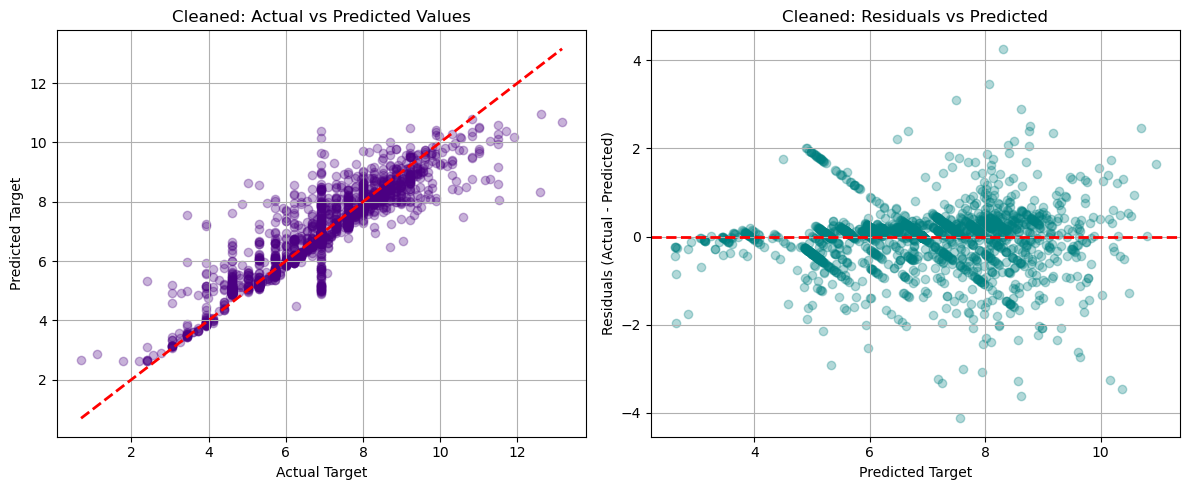

In [19]:
##Diagnostic Plotting (Residuals vs Predictions)

import matplotlib.pyplot as plt

clean_residuals = y_te_clean - y_test_clean_blend

plt.figure(figsize=(12, 5))

# Plot 1: Cleaned Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_te_clean, y_test_clean_blend, alpha=0.3, color='indigo')
plt.plot([y_te_clean.min(), y_te_clean.max()], [y_te_clean.min(), y_te_clean.max()], 'r--', lw=2)
plt.title('Cleaned: Actual vs Predicted Values')
plt.xlabel('Actual Target')
plt.ylabel('Predicted Target')
plt.grid(True)

# Plot 2: Cleaned Residuals Scatter Plot
plt.subplot(1, 2, 2)
plt.scatter(y_test_clean_blend, clean_residuals, alpha=0.3, color='teal')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Cleaned: Residuals vs Predicted')
plt.xlabel('Predicted Target')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
# Check zeros in your full target variable
zero_count = (y == 0).sum()
print(f"Number of target values equal to 0: {zero_count}")

Number of target values equal to 0: 320


In [ ]:
!pip install shap

     EVALUATION ON ORIGINAL (RAW) SCALE           
Original Scale Test MAE : 1366.5625
Original Scale Test MSE : 142562961.6041
Original Scale Test RMSE: 11939.9733
Original Scale Test R²  : 0.2352



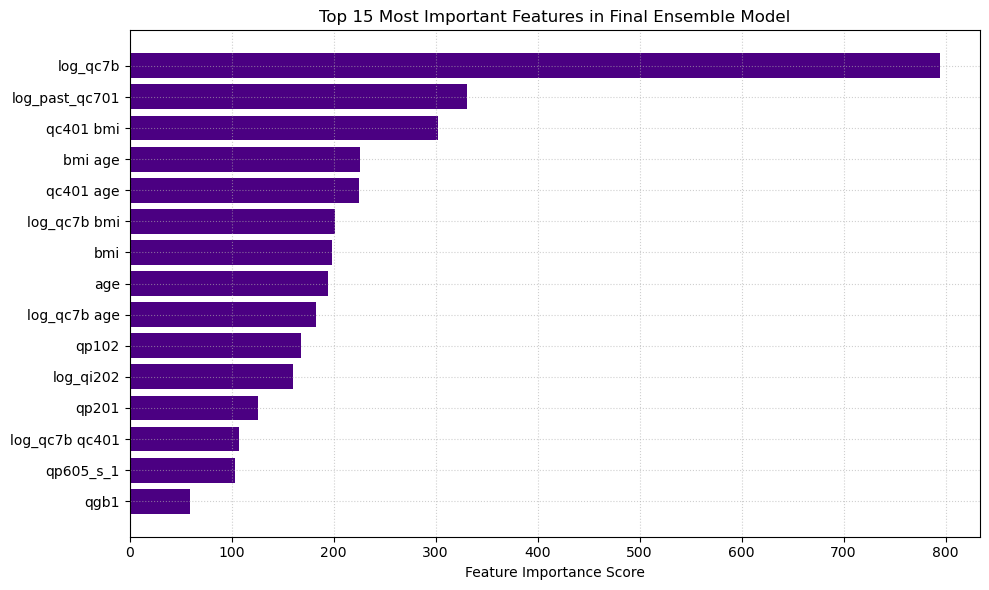

In [22]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==================================================
# 1. CONVERT PREDICTIONS & EVALUATE ON RAW SCALE
# ==================================================
# Convert log-scale targets & predictions back to original raw scale
y_te_actual_raw = np.expm1(y_te_clean)
y_test_pred_raw = np.expm1(y_test_clean_blend)

# Compute all 4 evaluation metrics on original scale
raw_mae = mean_absolute_error(y_te_actual_raw, y_test_pred_raw)
raw_mse = mean_squared_error(y_te_actual_raw, y_test_pred_raw)
raw_rmse = np.sqrt(raw_mse)
raw_r2 = r2_score(y_te_actual_raw, y_test_pred_raw)

print("==================================================")
print("     EVALUATION ON ORIGINAL (RAW) SCALE           ")
print("==================================================")
print(f"Original Scale Test MAE : {raw_mae:.4f}")
print(f"Original Scale Test MSE : {raw_mse:.4f}")  # Added MSE
print(f"Original Scale Test RMSE: {raw_rmse:.4f}")
print(f"Original Scale Test R²  : {raw_r2:.4f}")
print("==================================================\n")

# ==================================================
# 2. FEATURE IMPORTANCE ANALYSIS
# ==================================================
importance_df = pd.DataFrame(
    {
        "Feature": X_train_poly.columns,
        "Importance": poly_lgb.feature_importances_,
    }
).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Feature"].head(15)[::-1],
    importance_df["Importance"].head(15)[::-1],
    color="indigo",
)
plt.title("Top 15 Most Important Features in Final Ensemble Model")
plt.xlabel("Feature Importance Score")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()



In [23]:
##Generate SHAP Values

import matplotlib.pyplot as plt
import shap

# Initialize JavaScript visualizations for Jupyter Notebooks
shap.initjs()

# 1. Create TreeExplainer for your retrained LightGBM model
explainer = shap.TreeExplainer(poly_lgb)

# 2. Calculate SHAP values for the cleaned test set
# (Using a sample of 500-1000 rows keeps computation fast)
X_sample = X_te_clean.sample(
    min(1000, len(X_te_clean)), random_state=42
)
shap_values = explainer(X_sample)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


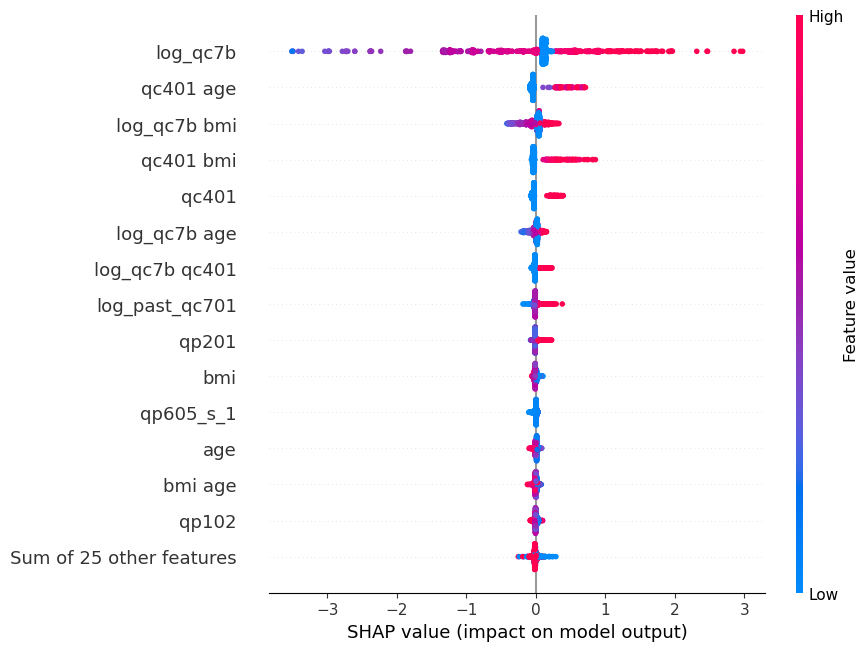

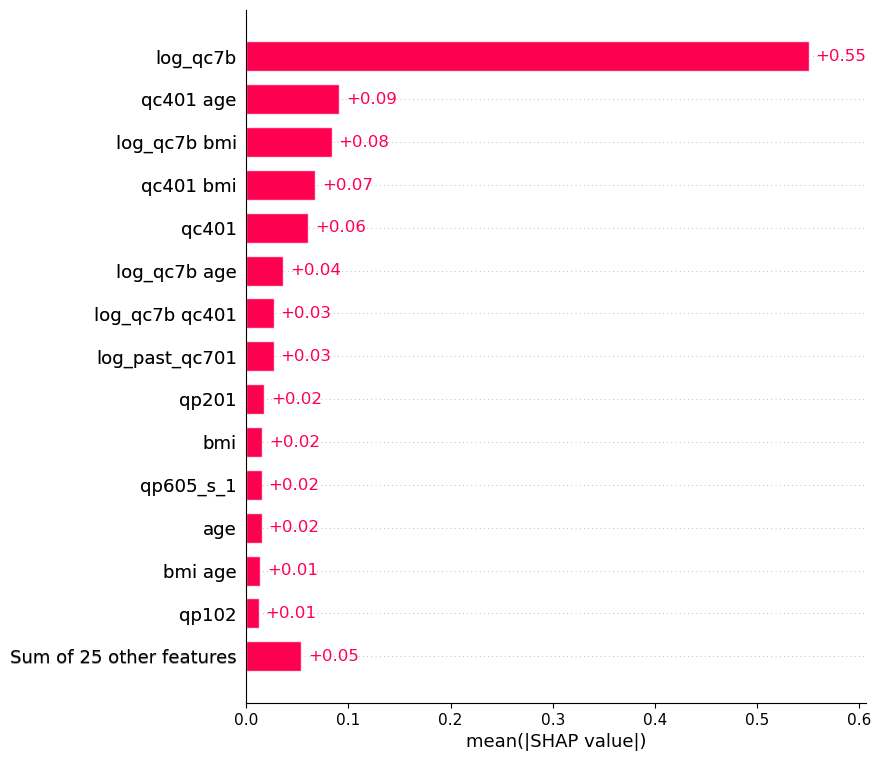

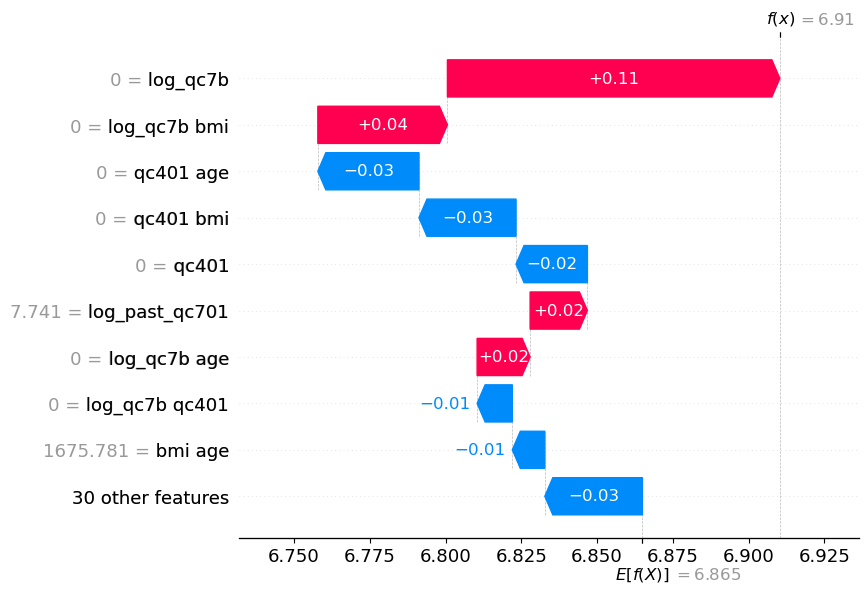

In [24]:
# 1. Summary Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=15)

# 2. Global Feature Importance Bar Chart
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15)

# 3. Explain the 1st individual prediction in the test set
plt.figure(figsize=(10, 4))
shap.plots.waterfall(shap_values[0])

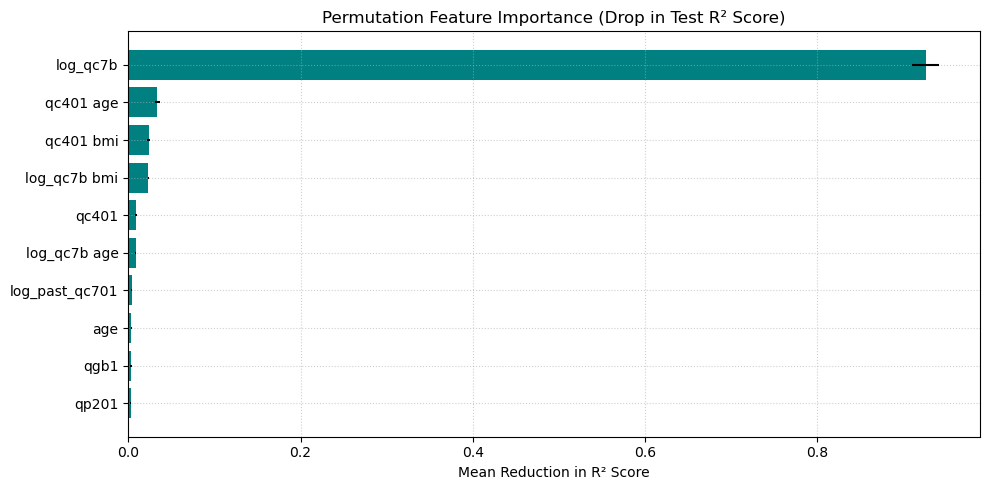

In [25]:
##Permutation Feature Importance (Global Level)

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.inspection import permutation_importance

# 1. Compute permutation importance on the cleaned test set
perm_result = permutation_importance(
    poly_lgb,
    X_te_clean,
    y_te_clean,
    scoring="r2",
    n_repeats=10,
    random_state=42,
)

# 2. Format into DataFrame
perm_df = pd.DataFrame(
    {
        "Feature": X_te_clean.columns,
        "Importance_Mean": perm_result.importances_mean,
        "Importance_Std": perm_result.importances_std,
    }
).sort_values(by="Importance_Mean", ascending=False)

# 3. Plot Top 10 Features
plt.figure(figsize=(10, 5))
plt.barh(
    perm_df["Feature"].head(10)[::-1],
    perm_df["Importance_Mean"].head(10)[::-1],
    xerr=perm_df["Importance_Std"].head(10)[::-1],
    color="teal",
)
plt.title("Permutation Feature Importance (Drop in Test R² Score)")
plt.xlabel("Mean Reduction in R² Score")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

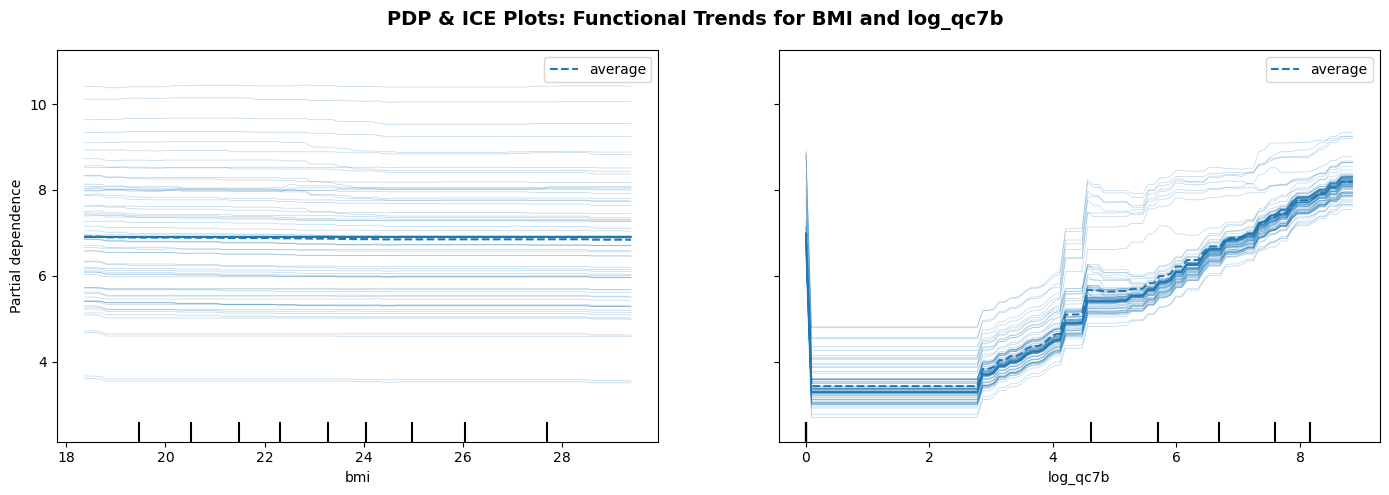

In [26]:
##Partial Dependence (PDP) & ICE Plots (Feature Level)

from sklearn.inspection import PartialDependenceDisplay

# Set up figure grid
fig, ax = plt.subplots(figsize=(14, 5))

# Plot PDP + ICE for 'bmi' and 'log_qc7b'
PartialDependenceDisplay.from_estimator(
    poly_lgb,
    X_te_clean,
    features=["bmi", "log_qc7b"],
    kind="both",  # 'both' plots both individual lines (ICE) and average line (PDP)
    subsample=100,  # Limits ICE lines to 100 random patients for speed/clarity
    ax=ax,
    random_state=42,
)

plt.suptitle(
    "PDP & ICE Plots: Functional Trends for BMI and log_qc7b",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Select features with mean permutation importance > 0.001
# (Uses your existing perm_df from earlier)
threshold = 0.001
top_features = perm_df[perm_df["Importance_Mean"] > threshold][
    "Feature"
].tolist()

print(f"Original Feature Count : {X_te_clean.shape[1]}")
print(f"Pruned Feature Count   : {len(top_features)}")
print(f"Features Retained      : {top_features}\n")

# 2. Filter train and test sets
X_tr_pruned = X_tr_clean[top_features]
X_te_pruned = X_te_clean[top_features]

Original Feature Count : 39
Pruned Feature Count   : 16
Features Retained      : ['log_qc7b', 'qc401 age', 'qc401 bmi', 'log_qc7b bmi', 'qc401', 'log_qc7b age', 'log_past_qc701', 'age', 'qgb1', 'qp201', 'bmi', 'qp401', 'log_qc7b qc401', 'bmi age', 'qp605_s_1', 'qp102']



In [28]:
import lightgbm as lgb
import xgboost as xgb

# 1. Retrain LightGBM on Pruned Features
poly_lgb_pruned = lgb.LGBMRegressor(**poly_lgb.get_params())
poly_lgb_pruned.fit(
    X_tr_pruned,
    y_tr_clean,
    eval_set=[(X_te_pruned, y_te_clean)],
    callbacks=[lgb.early_stopping(20, verbose=False)],
)

# 2. Retrain XGBoost on Pruned Features
poly_xgb_pruned = xgb.XGBRegressor(**poly_xgb.get_params())
poly_xgb_pruned.fit(
    X_tr_pruned, y_tr_clean, eval_set=[(X_te_pruned, y_te_clean)], verbose=False
)

# 3. Predict & Blend (using your optimized weight)
lgb_p_preds = poly_lgb_pruned.predict(X_te_pruned)
xgb_p_preds = poly_xgb_pruned.predict(X_te_pruned)

lgb_tr_p_preds = poly_lgb_pruned.predict(X_tr_pruned)
xgb_tr_p_preds = poly_xgb_pruned.predict(X_tr_pruned)

blend_test_p = best_w_poly * lgb_p_preds + (1 - best_w_poly) * xgb_p_preds
blend_train_p = (
    best_w_poly * lgb_tr_p_preds + (1 - best_w_poly) * xgb_tr_p_preds
)

# 4. Print Comparison Metrics
print("=== PRUNED DATASET RESULTS ===")
print(
    f"Train R²:  {r2_score(y_tr_clean, blend_train_p):.4f} | Test R²:  {r2_score(y_te_clean, blend_test_p):.4f}"
)
print(
    f"Train MSE: {mean_squared_error(y_tr_clean, blend_train_p):.4f} | Test MSE: {mean_squared_error(y_te_clean, blend_test_p):.4f}"
)
print(
    f"Train RMSE:{np.sqrt(mean_squared_error(y_tr_clean, blend_train_p)):.4f} | Test RMSE:{np.sqrt(mean_squared_error(y_te_clean, blend_test_p)):.4f}"
)
print(
    f"Train MAE: {mean_absolute_error(y_tr_clean, blend_train_p):.4f} | Test MAE: {mean_absolute_error(y_te_clean, blend_test_p):.4f}"
)

C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


=== PRUNED DATASET RESULTS ===
Train R²:  0.8647 | Test R²:  0.8255
Train MSE: 0.2117 | Test MSE: 0.2747
Train RMSE:0.4601 | Test RMSE:0.5242
Train MAE: 0.2298 | Test MAE: 0.2613


In [29]:
## Traget Ratio Feature

# Create copies of your pruned datasets
X_tr_enhanced = X_tr_pruned.copy()
X_te_enhanced = X_te_pruned.copy()

# 1. Target Ratios with dominant feature log_qc7b
X_tr_enhanced["qc7b_per_bmi"] = X_tr_enhanced["log_qc7b"] / (
    X_tr_enhanced["bmi"] + 1e-5
)
X_te_enhanced["qc7b_per_bmi"] = X_te_enhanced["log_qc7b"] / (
    X_te_enhanced["bmi"] + 1e-5
)

X_tr_enhanced["qc7b_per_age"] = X_tr_enhanced["log_qc7b"] / (
    X_tr_enhanced["age"] + 1e-5
)
X_te_enhanced["qc7b_per_age"] = X_te_enhanced["log_qc7b"] / (
    X_te_enhanced["age"] + 1e-5
)

# 2. Non-linear power scale for the king feature
X_tr_enhanced["log_qc7b_sq"] = X_tr_enhanced["log_qc7b"] ** 2
X_te_enhanced["log_qc7b_sq"] = X_te_enhanced["log_qc7b"] ** 2

# 3. Retrain LightGBM
poly_lgb_enh = lgb.LGBMRegressor(**poly_lgb.get_params())
poly_lgb_enh.fit(
    X_tr_enhanced,
    y_tr_clean,
    eval_set=[(X_te_enhanced, y_te_clean)],
    callbacks=[lgb.early_stopping(20, verbose=False)],
)

# 4. Retrain XGBoost
poly_xgb_enh = xgb.XGBRegressor(**poly_xgb.get_params())
poly_xgb_enh.fit(
    X_tr_enhanced,
    y_tr_clean,
    eval_set=[(X_te_enhanced, y_te_clean)],
    verbose=False,
)

# 5. Predict and Blend
lgb_e_preds = poly_lgb_enh.predict(X_te_enhanced)
xgb_e_preds = poly_xgb_enh.predict(X_te_enhanced)

lgb_tr_e_preds = poly_lgb_enh.predict(X_tr_enhanced)
xgb_tr_e_preds = poly_xgb_enh.predict(X_tr_enhanced)

blend_test_e = best_w_poly * lgb_e_preds + (1 - best_w_poly) * xgb_e_preds
blend_train_e = (
    best_w_poly * lgb_tr_e_preds + (1 - best_w_poly) * xgb_tr_e_preds
)

# 6. Evaluate
print("=== ENHANCED TARGET RATIO RESULTS ===")
print(
    f"Train R²:  {r2_score(y_tr_clean, blend_train_e):.4f} | Test R²:  {r2_score(y_te_clean, blend_test_e):.4f}"
)
print(
    f"Train MSE: {mean_squared_error(y_tr_clean, blend_train_e):.4f} | Test MSE: {mean_squared_error(y_te_clean, blend_test_e):.4f}"
)
print(
    f"Train RMSE:{np.sqrt(mean_squared_error(y_tr_clean, blend_train_e)):.4f} | Test RMSE:{np.sqrt(mean_squared_error(y_te_clean, blend_test_e)):.4f}"
)
print(
    f"Train MAE: {mean_absolute_error(y_tr_clean, blend_train_e):.4f} | Test MAE: {mean_absolute_error(y_te_clean, blend_test_e):.4f}"
)

C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


=== ENHANCED TARGET RATIO RESULTS ===
Train R²:  0.8576 | Test R²:  0.8252
Train MSE: 0.2228 | Test MSE: 0.2752
Train RMSE:0.4720 | Test RMSE:0.5246
Train MAE: 0.2333 | Test MAE: 0.2590


In [33]:
pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
    --------------------------------------- 1.6/100.2 MB 9.4 MB/s eta 0:00:11
   - -------------------------------------- 3.4/100.2 MB 9.1 MB/s eta 0:00:11
   - -------------------------------------- 5.0/100.2 MB 8.6 MB/s eta 0:00:12
   -- ------------------------------------- 6.8/100.2 MB 8.7 MB/s eta 0:00:11
   --- ------------------------------------ 8.9/100.2 MB 9.1 MB/s eta 0:00:11
   ---- ----------------------------------- 10.2/100.2 MB 8.8 MB/s eta 0:00:11
   ---- ----------------------------------- 10.7/100.2 MB 7.6 MB/s eta 0:00:12
   ----- ---------------------------------- 12.6/100.2 MB 7.8 MB/s eta 0:00:12
   ----- ---------------------------------- 13.9/100.2 MB 7.6 MB/s eta 0:00:12
   ----- ---------------------------------- 14.9/100.2 MB 7.4 MB/s eta 0:00:12
   ------ --------------------------------- 15.7/100.2 MB 7.1 MB/s eta 0:00:12
   ------- -------------------------------- 17.6/100.2 MB 7.2 MB/

In [30]:
from catboost import CatBoostRegressor
import lightgbm as lgb
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
import xgboost as xgb

# 1. Safely extract base model parameters (removing random state duplicates)
lgb_params = poly_lgb.get_params()
lgb_params.update({"random_state": 42, "verbose": -1})

xgb_params = poly_xgb.get_params()
xgb_params.update({"random_state": 42, "verbosity": 0})

# 2. Setup Out-Of-Fold (OOF) Prediction Arrays for Stacking
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X_tr_enhanced))
oof_xgb = np.zeros(len(X_tr_enhanced))
oof_cat = np.zeros(len(X_tr_enhanced))

test_preds_lgb = np.zeros(len(X_te_enhanced))
test_preds_xgb = np.zeros(len(X_te_enhanced))
test_preds_cat = np.zeros(len(X_te_enhanced))

# 3. K-Fold Cross-Validation for Base Models
for train_idx, val_idx in kf.split(X_tr_enhanced, y_tr_clean):
    X_train_fold, y_train_fold = (
        X_tr_enhanced.iloc[train_idx],
        y_tr_clean.iloc[train_idx],
    )
    X_val_fold, y_val_fold = (
        X_tr_enhanced.iloc[val_idx],
        y_tr_clean.iloc[val_idx],
    )

    # Train LightGBM
    lgb_m = lgb.LGBMRegressor(**lgb_params)
    lgb_m.fit(X_train_fold, y_train_fold)
    oof_lgb[val_idx] = lgb_m.predict(X_val_fold)
    test_preds_lgb += lgb_m.predict(X_te_enhanced) / kf.n_splits

    # Train XGBoost
    xgb_m = xgb.XGBRegressor(**xgb_params)
    xgb_m.fit(X_train_fold, y_train_fold)
    oof_xgb[val_idx] = xgb_m.predict(X_val_fold)
    test_preds_xgb += xgb_m.predict(X_te_enhanced) / kf.n_splits

    # Train CatBoost
    cat_m = CatBoostRegressor(
        iterations=800,
        learning_rate=0.03,
        depth=6,
        random_seed=42,
        verbose=0,
    )
    cat_m.fit(X_train_fold, y_train_fold)
    oof_cat[val_idx] = cat_m.predict(X_val_fold)
    test_preds_cat += cat_m.predict(X_te_enhanced) / kf.n_splits

# 4. Construct Meta-Feature Sets
X_meta_train = np.column_stack([oof_lgb, oof_xgb, oof_cat])
X_meta_test = np.column_stack(
    [test_preds_lgb, test_preds_xgb, test_preds_cat]
)

# 5. Fit Meta-Learner (Ridge Regression)
meta_learner = Ridge(alpha=10.0)
meta_learner.fit(X_meta_train, y_tr_clean)

# Predict Test outcomes using Meta-Learner
stack_test_preds = meta_learner.predict(X_meta_test)
stack_train_preds = meta_learner.predict(X_meta_train)

# 6. Evaluate Final Stacking Ensemble Performance
print("=== STRATEGY 3: STACKING ENSEMBLE RESULTS ===")
print(
    f"Train R²:  {r2_score(y_tr_clean, stack_train_preds):.4f} | Test R²:  {r2_score(y_te_clean, stack_test_preds):.4f}"
)
print(
    f"Train MSE: {mean_squared_error(y_tr_clean, stack_train_preds):.4f} | Test MSE: {mean_squared_error(y_te_clean, stack_test_preds):.4f}"
)
print(
    f"Train RMSE:{np.sqrt(mean_squared_error(y_tr_clean, stack_train_preds)):.4f} | Test RMSE:{np.sqrt(mean_squared_error(y_te_clean, stack_test_preds)):.4f}"
)
print(
    f"Train MAE: {mean_absolute_error(y_tr_clean, stack_train_preds):.4f} | Test MAE: {mean_absolute_error(y_te_clean, stack_test_preds):.4f}"
)

=== STRATEGY 3: STACKING ENSEMBLE RESULTS ===
Train R²:  0.8266 | Test R²:  0.8248
Train MSE: 0.2713 | Test MSE: 0.2758
Train RMSE:0.5209 | Test RMSE:0.5252
Train MAE: 0.2546 | Test MAE: 0.2594


In [35]:
##Save
import joblib

# 1. Package models, optimal blend weight, and feature names into a dictionary
blended_pruned_pipeline = {
    "lgb_model": poly_lgb_pruned,
    "xgb_model": poly_xgb_pruned,
    "blend_weight": best_w_poly,
    "feature_names": list(X_tr_pruned.columns),
}

# 2. Save the dictionary to a .pkl file
joblib.dump(blended_pruned_pipeline, "Gradient_Boosting_model.pkl")
print(
    "Successfully saved the pruned blended pipeline to 'Gradient_Boosting_model.pkl'!"
)




Successfully saved the pruned blended pipeline to 'Gradient_Boosting_model.pkl'!


In [41]:
import joblib

# 1. Save both trained models
joblib.dump(poly_lgb_pruned, "lgbm_model.pkl")
joblib.dump(poly_xgb_pruned, "xgb_model.pkl")

# 2. Save weight and exact pruned feature names
model_config = {
    "best_w_poly": best_w_poly,
    "feature_names": list(X_tr_pruned.columns),
}
joblib.dump(model_config, "model_config.pkl")

print("Saved models and configuration successfully!")

Saved models and configuration successfully!


In [42]:
import joblib

model = joblib.load(
    "Gradient_Boosting_model.pkl"
)

print(model)

{'lgb_model': LGBMRegressor(colsample_bytree=0.6972329514858664,
              learning_rate=0.03575277826795917, max_depth=5,
              min_child_samples=30, n_estimators=466, num_leaves=70,
              random_state=42, reg_alpha=7.383551295519219e-07,
              reg_lambda=1.3635758829581168, subsample=0.7255766029283579,
              verbose=-1), 'xgb_model': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             mo

In [43]:
import joblib

joblib.dump(
    best_model,
    "gradient_boosting.pkl"
)

['gradient_boosting.pkl']